# EXERCISE - Counting objects workflow (batch)

---
*Introduction to Image Analysis Workshop*

*Stefania Marcotti (stefania.marcotti@crick.ac.uk)*

*Intro to building batch image analysis pipelines with Python*

*CC-BY-SA-4.0 license: creativecommons.org/licenses/by-sa/4.0/*

---

Following on from the previous [notebook](https://github.com/RMS-DAIM/introduction-to-image-analysis/tree/main/Scripts/Jupyter/counting_objects.ipynb), we run the same pipeline on all the images available in the [`Data/idr0028`](https://github.com/RMS-DAIM/introduction-to-image-analysis/tree/main/Data/idr0028) folder. 

Fill in the gaps `[...]` in the notebook and look at the Tasks as you go through to achieve the batch analysis. Solutions are available in the Scripts folder, but please give it a good try first! Also, try not to use ChatGPT (but Google is allowed!)

### Import libraries

Note we are importing also the library `os` (API [here](https://docs.python.org/3/library/os.html)) which provides miscellaneous operating system interfaces.

In [49]:
import os

import numpy as np

from skimage import io
from skimage import filters
from skimage import measure
from skimage import segmentation

import matplotlib.pyplot as plt

import pandas as pd

### Import data
This time we are reading all of the files in the folder - note the use of the wildcard `*`!

In [50]:
# get the list of all files and directories
path = '../../Data/idr0028/'
dir_list = os.listdir(path)

print(*dir_list, sep='\n')

.ipynb_checkpoints
003003-10.tif
003003-11.tif
003003-12.tif
003003-13.tif
003003-14.tif
003003-15.tif
003003-16.tif
003003-17.tif
003003-18.tif
003003-19.tif
Results.csv
edited


In [51]:
# read all .tif files in folder
im_read = io.imread('../../Data/idr0028/*.tif')

In [52]:
# check the dimensions of the object
print('Object dimensions:', im_read.shape)

Object dimensions: (10, 501, 667, 4)


<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> The image dimensions are currently in the (n, y, x, c) format. Ideally, by convention, we would want the dimensions of the image to be (n, c, x, y). We can rearrange the dimensions by using the numpy function <code>transpose</code>.</div>

In [53]:
im_all = np.transpose(im_read, (0, 3, 1, 2))
print('New object dimensions:', im_all.shape)

New object dimensions: (10, 4, 501, 667)


<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> We can visualise some example nuclear images by running the cell below. The variable <code>im_idx</code> indicates which image we want to open (first=0, second=1, ...); how do we select the correct image from <code>im_all</code>?</div>

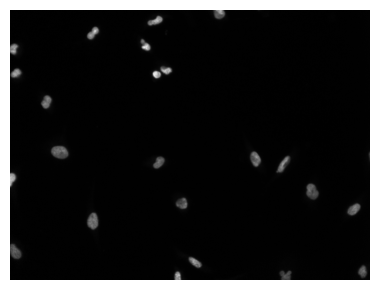

In [54]:
# select image
im_idx = 0
channel = 0  # 0, 1, 2, or 3

im = im_all[im_idx, channel, :, :]

# display the chosen image
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(im, cmap='gray')
ax.axis('off')
plt.tight_layout()

### Perform the analysis on one image at the time

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> By using a <code>for</code> loop, we can open one image at the time, and perform the same exact pipeline as before to count the objects and measure their area and eccentricity. We can use the numpy function <code>append</code> to save the results for object count in an array called <code>obj_count</code> and create a pandas dataframe called <code>props_df</code> where each row represents one object and each column one measurement (hint! You might need the pandas function <code>concat</code> with the flag <code>ignore_index=True</code>).</div>

In [84]:
# initialise output
channel = 0 # this is the nuclear channel
obj_count = []
props_df = pd.DataFrame()
output_folder = path + "label_imgs/"

# set up for loop for all the images available in the folder
for i in range(len(im_all)):
    img_name = dir_list[i + 1]
    img = im_all[i]
    im = img[channel, :, :]
    # Gaussian blur (sigma=2)
    im_gauss = filters.gaussian(im, sigma=2)
    # apply thresholding
    thresh = filters.threshold_otsu(im_gauss)
    im_thresh = im_gauss >= thresh
    # labelling
    labels = measure.label(im_thresh)
    # clear border
    labels_wo_border = segmentation.clear_border(labels)
    # save the image
    io.imsave(f"{output_folder}label_img_{img_name}", labels_wo_border)
    props = measure.regionprops_table(labels_wo_border, properties=['label', 'area', 'centroid', 'eccentricity'])
    props_df_temp = pd.DataFrame(props)
    props_df_temp['img'] = img_name
    num_obj = len(props_df_temp)
    # append to the output
    obj_count = np.append(obj_count, num_obj)
    props_df = pd.concat([props_df, props_df_temp], ignore_index=True)

print(obj_count)
print(props_df)
 

/opt/miniconda3/envs/introIA-env/lib/python3.10/site-packages/skimage/_shared/utils.py:328: UserWarning: ../../Data/idr0028/label_imgs/label_img_003003-10.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/introIA-env/lib/python3.10/site-packages/skimage/_shared/utils.py:328: UserWarning: ../../Data/idr0028/label_imgs/label_img_003003-11.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/introIA-env/lib/python3.10/site-packages/skimage/_shared/utils.py:328: UserWarning: ../../Data/idr0028/label_imgs/label_img_003003-12.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/introIA-env/lib/python3.10/site-packages/skimage/_shared/utils.py:328: UserWarning: ../../Data/idr0028/label_imgs/label_img_003003-13.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/introIA-env/lib/python3.10/site-packages/skimage/_shared/utils.py:328: UserWarning: ../../Data/idr0028/label_imgs/label_img

[16. 19. 18. 28. 29. 27. 20.  7. 24. 31.]
     label   area  centroid-0  centroid-1  eccentricity            img
0        2  349.0   19.982808  269.472779      0.888196  003003-10.tif
1        3  338.0   42.588757  153.600592      0.854779  003003-10.tif
2        4  297.0   65.919192  250.579125      0.779027  003003-10.tif
3        6  525.0  114.998095  280.680000      0.912575  003003-10.tif
4        7  277.0  117.072202   10.703971      0.643164  003003-10.tif
..     ...    ...         ...         ...           ...            ...
214     29  329.0  399.550152  570.148936      0.734937  003003-19.tif
215     30  456.0  412.692982  434.083333      0.849275  003003-19.tif
216     31  514.0  450.219844  612.819066      0.803033  003003-19.tif
217     32  948.0  474.738397  493.647679      0.730135  003003-19.tif
218     33  980.0  473.358163   44.825510      0.725421  003003-19.tif

[219 rows x 6 columns]


/opt/miniconda3/envs/introIA-env/lib/python3.10/site-packages/skimage/_shared/utils.py:328: UserWarning: ../../Data/idr0028/label_imgs/label_img_003003-19.tif is a low contrast image
  return func(*args, **kwargs)


In [71]:
# print output [obj_count]
print('The number of nuclei for each image is:', obj_count)

The number of nuclei for each image is: [16. 19. 18. 28. 29. 27. 20.  7. 24. 31.]


In [72]:
for im_idx in range(im_all.shape[0]):
    print('The number of nuclei in', dir_list[im_idx], 'is', obj_count[im_idx])

The number of nuclei in .ipynb_checkpoints is 16.0
The number of nuclei in 003003-10.tif is 19.0
The number of nuclei in 003003-11.tif is 18.0
The number of nuclei in 003003-12.tif is 28.0
The number of nuclei in 003003-13.tif is 29.0
The number of nuclei in 003003-14.tif is 27.0
The number of nuclei in 003003-15.tif is 20.0
The number of nuclei in 003003-16.tif is 7.0
The number of nuclei in 003003-17.tif is 24.0
The number of nuclei in 003003-18.tif is 31.0


In [73]:
# show the beginning of the properties dataframe
props_df.head()

,label,area,centroid-0,centroid-1,eccentricity,img
0,2,349.0,19.982808,269.472779,0.888196,003003-10.tif
1,3,338.0,42.588757,153.600592,0.854779,003003-10.tif
2,4,297.0,65.919192,250.579125,0.779027,003003-10.tif
3,6,525.0,114.998095,280.680000,0.912575,003003-10.tif
4,7,277.0,117.072202,10.703971,0.643164,003003-10.tif


In [74]:
# how many nuclei did we analyse?
print('We analysed', len(props_df), 'nuclei in', im_all.shape[0], 'images')

We analysed 219 nuclei in 10 images


### Plot some results

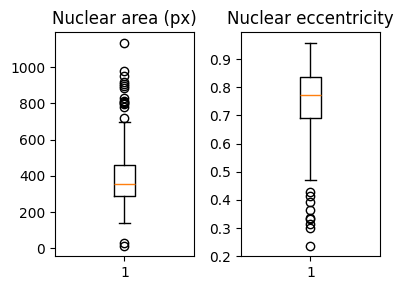

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(4,3))

axs[0].boxplot(props_df['area'])
axs[0].set_title('Nuclear area (px)')

axs[1].boxplot(props_df['eccentricity'])
axs[1].set_title('Nuclear eccentricity')

plt.tight_layout()

### Save outputs

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> We can save the <code>props_df</code> dataframe as an Excel file with the pandas function <code>to_excel</code>.</div>

In [76]:
# save dataframe as excel file

props_df.to_excel("../../output/idr0028_props_df.xlsx")

<div style="background-color:#c1c3d7; border-radius: 5px; padding: 10pt"><strong>Task (difficult!)</strong> We can save the label images using a function called <code>imsave</code> inside the <code>skimage.io</code> module. This will require setting up another <code>for</code> loop and think of a way to work with output file names. Give it a go!</div>

In [ ]:
# save label images
[...]

### Further reading
If you're interested in knowing more about image analysis in Python, there are a lot of free resources out there! One good starting point is the [IAFIG-RMS Python for Bioimage Analysis Course](https://github.com/RMS-DAIM/Python-for-Bioimage-Analysis). Good luck with your image analysis adventures!